In [4]:
### Code to read in h5 files as detailed in the first guidebook
# Import necessary packages
import sys
sys.path.append(r'C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts')
from spectral_sediment import calculate_sed_stats, despiker
import pandas as pd
import os
import datetime 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
plt.rcParams.update({'font.size': 14}) 


In [5]:
deployment_num = [1,2]
sensor_id = ["S1_101418", "E1_103071", "S0_103080"]
#directory_initial_user_path = r"/Volumes/BOEM/"  # Katherine
# directory_initial_user_path = r"/Volumes/kanarde/BOEM/"  # Brooke
directory_initial_user_path = r"Z:/"  # Levi

In [6]:
# Create dictionary for each sensor
for dep in deployment_num:
    for sensor in sensor_id:
        dirpath=os.path.join(directory_initial_user_path, f"deployment_{dep}/BulkStats/",sensor)
        files = os.listdir(dirpath) # list of files for the sensor
        waves = {}
        for file in files:
            file_path = os.path.join(dirpath, file)  # file path
            df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
            file_name = file.split('.')[0]  # file name 
            print(file_name)
            waves[file_name] = df  # store dataframe
        globals()[f"waves_D{dep}_{sensor}"] = waves

GroupSpeed
Frequencies
WaveNumbers
Time
WaveCelerity
MeanPeriod
SignificantWaveHeight
VolumetricBackscatter1
Echo1avg
MeanDirection1
Echo2avg
MeanDirection2
MeanSpread2
Vertavg
PressureSpectra
PressureEastVelCospectra
PressureNorthVelCospectra
EastVelSpectra
NorthVelSpectra
MeanSpread1
DepthAveragedFlowDirection
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
DepthAveragedUpVelocity
DepthAveragedCurrentVelocity
SedTime
TargetStrength
BottomhalfScatterersavg
TophalfScatterersavg
TopVolumetricBackscatter1
BotVolumetricBackscatter1
Pressure
FullEastVelocity
FullNorthVelocity
FullUpVelocity
GroupSpeed
Frequencies
WaveNumbers
Time
WaveCelerity
MeanPeriod
SignificantWaveHeight
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
DepthAveragedUpVelocity
DepthAveragedCurrentVelocity
MeanDirection1
MeanSpread1
MeanDirection2
MeanSpread2
DepthAveragedFlowDirection
PressureSpectra
PressureEastVelCospectra
PressureNorthVelCospectra
EastVelSpectra
NorthVelSpectra
VolumetricBackscatter1
Echo1av

In [7]:
# waves_D2_E1_103071['Echo1avg'] = pd.concat([waves_D2_E1_103071['Echo1avg'],pd.DataFrame([np.nan])], ignore_index=True, axis=0)

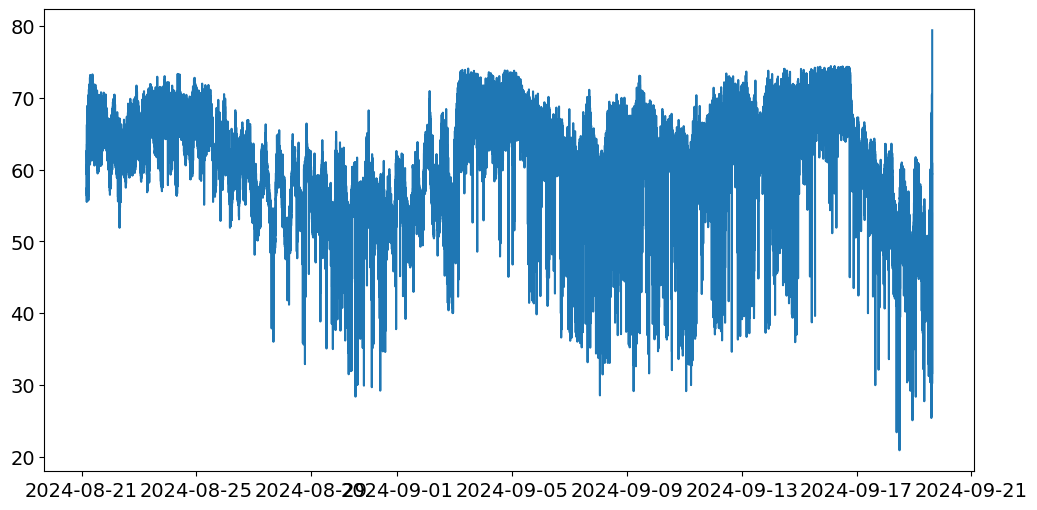

0   2024-08-21 04:20:00.188588
Name: 0, dtype: datetime64[ns]


In [8]:
plt.figure(figsize=(12,6))
plt.plot(waves_D1_E1_103071['SedTime'],waves_D1_E1_103071['Echo1avg'])
plt.show()

print(waves_D1_E1_103071['SedTime'].iloc[0])

In [9]:
print(len(waves["Vertavg"]/4)-1000)
print(86400*28)

8984600
2419200


In [10]:
Sediment_D1_E1_103071 = calculate_sed_stats(
    waves_D1_E1_103071["SedTime"],
    waves_D1_E1_103071["Echo1avg"],
    event_time=datetime.datetime(2024, 9, 8, 20, 00),
    end_time=datetime.datetime(2024, 9, 19, 00, 00),
    fs=2,
    dtburst=86400 * 28,
    overlap=0.3,
    dtens=86400*28,
    mode="multitaper",
)

Sediment_D2_E1_103071 = calculate_sed_stats(
    waves_D2_E1_103071["SedTime"],
    waves_D2_E1_103071["Echo1avg"],
    event_time=datetime.datetime(2024, 11, 20, 00, 00),
    end_time=datetime.datetime(2024, 12, 9, 00, 00),
    fs=4,
    dtburst=86400 * 15,
    overlap=0.3,
    dtens=86400*15,
    mode="multitaper",
)

for sensor in sensor_id:
    if sensor != "E1_103071":
        waves = globals()[f"waves_D1_{sensor}"]
        Sediment = calculate_sed_stats(
        waves["SedTime"],
        waves["Vertavg"],
        event_time=datetime.datetime(2024, 9, 8, 20, 00),
        end_time=datetime.datetime(2024, 9, 19, 00, 00),
        fs=4,
        dtburst=86400 * 28,
        overlap=0.3,
        dtens=86400 * 28,
        mode="multitaper")
        globals()[f"Sediment_D1_{sensor}"] = Sediment
        print(f"Sediment_D1_{sensor} calculated")

for sensor in sensor_id:
    if sensor != "E1_103071":
        waves = globals()[f"waves_D2_{sensor}"]
        Sediment = calculate_sed_stats(
        waves["SedTime"],
        waves["Vertavg"],
        event_time=datetime.datetime(2024, 11, 20, 00, 00),
        end_time=datetime.datetime(2024, 12, 9, 00, 00),
        fs=4,
        dtburst=86400 * 15,
        overlap=0.3,
        dtens=86400 * 15,
        mode="multitaper")
        globals()[f"Sediment_D2_{sensor}"] = Sediment
        print(f"Sediment_D2_{sensor} calculated")
            

Sediment_D1_S1_101418 calculated
Sediment_D1_S0_103080 calculated
Sediment_D2_S1_101418 calculated
Sediment_D2_S0_103080 calculated


In [ ]:
import numpy as np
from scipy.signal.windows import dpss
from scipy.signal import butter, filtfilt


from scipy.signal.windows import dpss

def coherence_spectrum(u, v, A, fs, NW=3.0, Kmax=None, smooth_bins=7):
    """
    Multitaper coherence between U = u + i v and scalar A.

    u, v, A : 1D arrays (same length, same sampling)
    fs      : sampling rate (Hz)
    NW      : time-bandwidth product
    Kmax    : number of tapers (defaults to 2*NW - 1)
    smooth_bins : integer, moving-average smoothing in frequency
    """
    u = np.asarray(u, float).ravel()
    v = np.asarray(v, float).ravel()
    A = np.asarray(A, float).ravel()

    U = u + 1j * v

    # Demean & fill NaNs
    U -= np.nanmean(U)
    A -= np.nanmean(A)
    U = np.nan_to_num(U, nan=0.0)
    A = np.nan_to_num(A, nan=0.0)

    N = len(U)

    if Kmax is None:
        Kmax = int(2*NW - 1)

    tapers, eigs = dpss(N, NW, Kmax, return_ratios=True)

    Sxx = np.zeros(N, float)
    Syy = np.zeros(N, float)
    Sxy = np.zeros(N, complex)

    for k in range(Kmax):
        Uk = U * tapers[k]
        Ak = A * tapers[k]

        Xk = np.fft.fft(Uk)
        Yk = np.fft.fft(Ak)

        Sxx += np.abs(Xk)**2
        Syy += np.abs(Yk)**2
        Sxy += Yk * np.conj(Xk)

    Sxx /= Kmax
    Syy /= Kmax
    Sxy /= Kmax

    # Frequency smoothing
    if smooth_bins > 1:
        kern = np.ones(smooth_bins) / smooth_bins
        Sxx = np.convolve(Sxx, kern, mode="same")
        Syy = np.convolve(Syy, kern, mode="same")
        Sxy = np.convolve(Sxy, kern, mode="same")

    eps = 1e-12
    Coh_complex = Sxy / (np.sqrt(Sxx * Syy) + eps)

    f = np.fft.fftfreq(N, d=1/fs)
    pos = f > 0
    neg = f < 0
    f1 = f[neg]
    f = f[pos]
    Coh_complexp = Coh_complex[pos]
    Coh_complexn = Coh_complex[neg]

    Coh_magp = np.abs(Coh_complexp)
    Coh_magn = np.abs(Coh_complexn)
    Coh_phase = np.angle(Coh_complex)

    return f,f1, Coh_magp, Coh_magn, Coh_phase




def downsample_antialias(signal, fs, fs_new, order=4):
    
    signal = np.asarray(signal).squeeze().astype(float)

    if fs_new >= fs:
        raise ValueError("fs_new must be smaller than fs")

    # Integer decimation factor
    q = int(np.round(fs / fs_new))
    fs_eff = fs / q

    # Butterworth low-pass filter just below new Nyquist
    fc = 0.45 * fs_eff  # cutoff Hz
    b, a = butter(order, fc / (0.5 * fs), btype="low")

    # Adaptive pad length for safety
    padlen = min(3 * max(len(a), len(b)), signal.size - 1)

    y_filt = filtfilt(b, a, signal, padlen=padlen)
    y_ds = y_filt[::q]

    return y_ds, fs_eff


In [12]:
D1E1Uvel, mask = despiker(despiker(waves_D1_E1_103071['FullNorthVelocity'], 3)[0],3)
D1E1Vvel, mask = despiker(despiker(waves_D1_E1_103071['FullEastVelocity'], 3)[0],3)
D2E1Uvel, mask = despiker(despiker(waves_D2_E1_103071['FullNorthVelocity'], 3)[0],3)
D2E1Vvel, mask = despiker(despiker(waves_D2_E1_103071['FullEastVelocity'], 3)[0],3)
D1E1avg, mask = despiker(despiker(waves_D1_E1_103071['Echo1avg'], 3)[0],3)
D2E1avg, mask = despiker(despiker(waves_D2_E1_103071['Echo1avg'], 3)[0],3)

In [13]:
print(len(D1E1Uvel), len(waves_D1_E1_103071['FullEastVelocity']), len(D1E1avg), len(waves_D1_E1_103071['Vertavg']))

5140800 5140800 5242090 5242090


In [14]:
# Define tidal frequencies in cycles per day (cpd)
tidal_freqs_cpd = {
    'M2': 1.932,   # semidiurnal
    'K1': 1.003,   # diurnal
}

# Assign a color for each tidal constituent
colors = {
    'M2': 'red',
    'K1': 'cyan'
}

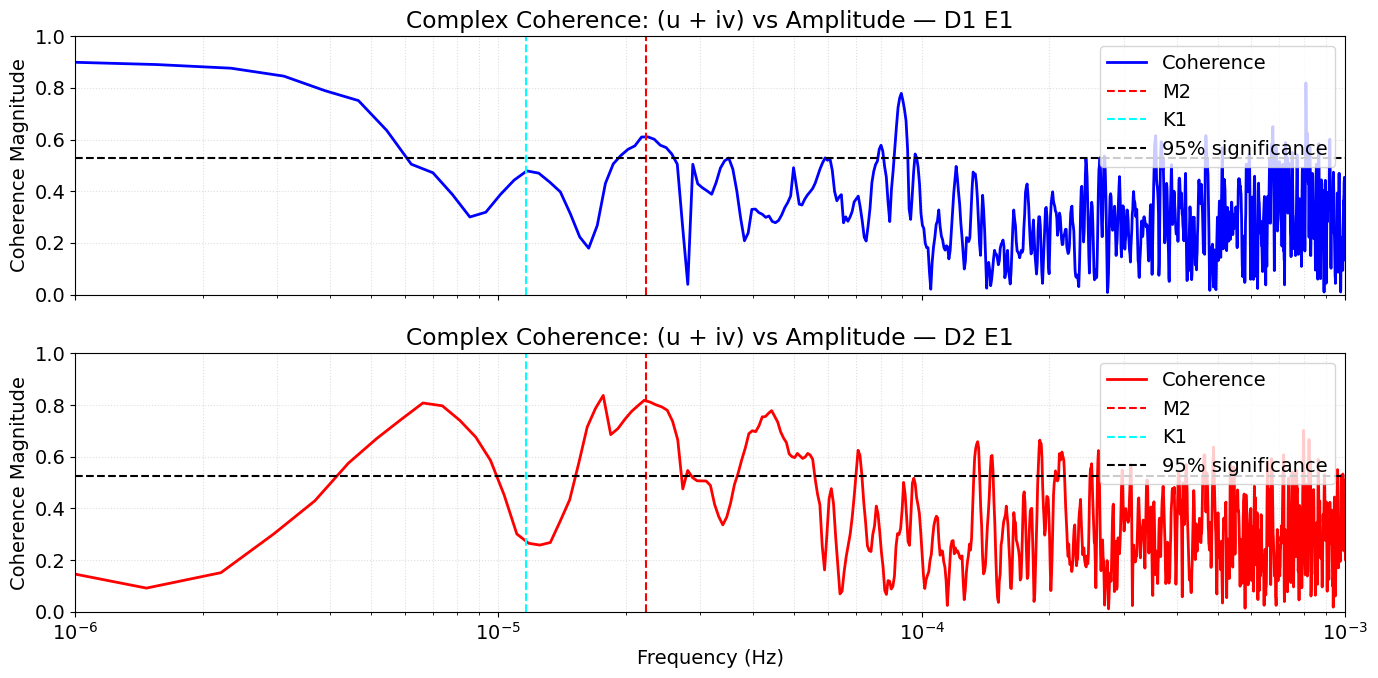

In [15]:
alpha = 0.05
k = 2*3 - 1  # K = 5 tapers → DOF ≈ 10

fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# =========================
# DEPLOYMENT 1
# =========================
N = len(D1E1Uvel)
mid = N // 2

U_front = D1E1Uvel[:mid]
V_front = D1E1Vvel[:mid]
A_front = D1E1avg[:mid]

fp, fn, Coh_magp, Coh_magn, Coh_phase = coherence_spectrum(
    U_front, V_front, A_front,
    fs=2,
    NW=3.0,
    smooth_bins=7
)

f_hz = fp   # <<< already in Hz

ax1.plot(
    f_hz, Coh_magp,
    color='blue',
    linewidth=2,
    label="Coherence"
)

# --- Tidal lines (cpd → Hz) ---
for name, f_cpd in tidal_freqs_cpd.items():
    f_hz_tide = f_cpd / 86400.0
    ax1.axvline(
        x=f_hz_tide,
        color=colors[name],
        linestyle="--",
        linewidth=1.5,
        label=name
    )

# --- 95% significance ---
ax1.axhline(
    y=1 - alpha**(1/(k-1)),
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='95% significance'
)

ax1.set_xscale("log")
ax1.set_ylabel("Coherence Magnitude")
ax1.set_title("Complex Coherence: (u + iv) vs Amplitude — D1 E1")
ax1.set_ylim(0, 1)
ax1.legend(loc='upper right')
ax1.grid(True, which="both", ls=":", alpha=0.4)

# =========================
# DEPLOYMENT 2
# =========================
fp, fn, Coh_magp, Coh_magn, Coh_phase = coherence_spectrum(
    D2E1Uvel, D2E1Vvel, D2E1avg,
    fs=4,
    NW=3.0,
    smooth_bins=7
)

f_hz = fp

ax2.plot(
    f_hz, Coh_magp,
    color='red',
    linewidth=2,
    label="Coherence"
)

for name, f_cpd in tidal_freqs_cpd.items():
    f_hz_tide = f_cpd / 86400.0
    ax2.axvline(
        x=f_hz_tide,
        color=colors[name],
        linestyle="--",
        linewidth=1.5,
        label=name
    )

ax2.axhline(
    y=1 - alpha**(1/(k-1)),
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='95% significance'
)

ax2.set_xscale("log")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Coherence Magnitude")
ax2.set_title("Complex Coherence: (u + iv) vs Amplitude — D2 E1")
ax2.set_ylim(0, 1)
ax2.legend(loc='upper right')
ax2.grid(True, which="both", ls=":", alpha=0.4)

# --- Log-safe x-limits (tides → waves) ---
for ax in [ax1, ax2]:
    ax.set_xlim(1e-6, 1e-3)   # adjust to Nyquist if needed

plt.tight_layout()
plt.show()


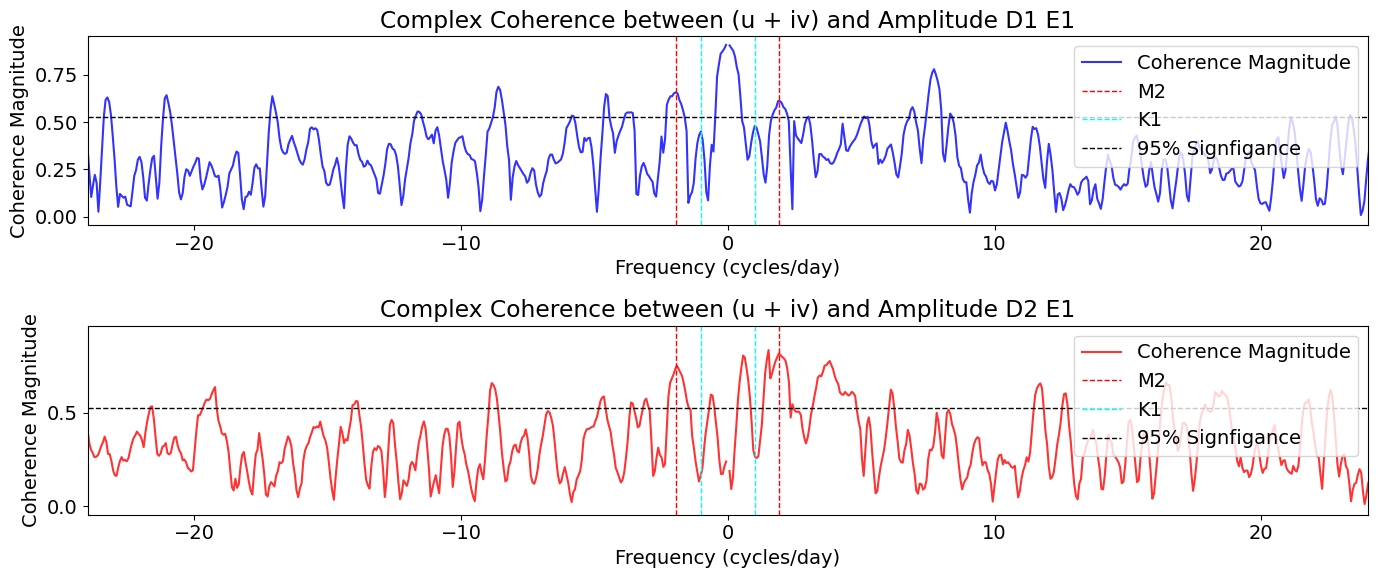

In [16]:
alpha = 0.05
k = 2*3 - 1  # number of tapers used in coherence calculation
N = len(D1E1Uvel)
mid = N // 2

U_front = D1E1Uvel[:mid]
V_front = D1E1Vvel[:mid]
A_front = D1E1avg[:mid]

# Multitaper coherence
fp,fn, Coh_magp, Coh_magn, Coh_phase = coherence_spectrum(
    U_front, V_front, A_front,
    fs=2,
    NW=3.0,          
    smooth_bins=7
)
f_cpdp = fp * 86400
f_cpdn = fn * 86400

# Only keep non-negative frequencies
fig,[ax1,ax2] = plt.subplots(2,1, figsize=(14, 6))

ax1.plot(f_cpdp, Coh_magp, label="Coherence Magnitude",color = 'blue', alpha=0.8)
ax1.plot(f_cpdn, Coh_magn, color = 'blue',label = '_nolegend_', alpha=0.8)

for name, f in tidal_freqs_cpd.items():
    ax1.axvline(x=f, color=colors[name], linestyle="--", linewidth=1, label=name)
for name, f in tidal_freqs_cpd.items():
    ax1.axvline(x=-f, color=colors[name], linestyle="--", linewidth=1, label='_nolegend_')
ax1.axhline(y = 1- alpha**(1/(k-1)), color = 'black', label = '95% Signfigance', linestyle = '--', linewidth=1)
ax1.set_xlabel("Frequency (cycles/day)")
ax1.set_ylabel("Coherence Magnitude")
ax1.set_title("Complex Coherence between (u + iv) and Amplitude D1 E1")
ax1.set_xlim(-24, 24)
ax1.legend(loc='upper right')

N = len(D2E1Uvel)
mid = N // 2

# Multitaper coherence
fp,fn, Coh_magp, Coh_magn, Coh_phase = coherence_spectrum(
    D2E1Uvel, D2E1Vvel, D2E1avg,
    fs=4,
    NW=3.0,          
    smooth_bins=7
)

f_cpdp = fp * 86400
f_cpdn = fn * 86400

ax2.plot(f_cpdp, Coh_magp, label="Coherence Magnitude",color = 'red', alpha=0.8)
ax2.plot(f_cpdn, Coh_magn,color = 'red',label = '_nolegend_', alpha=0.8)

for name, f in tidal_freqs_cpd.items():
        ax2.axvline(x=f, color=colors[name], linestyle="--", linewidth=1, label=name)
for name, f in tidal_freqs_cpd.items():
    ax2.axvline(x=-f, color=colors[name], linestyle="--", linewidth=1, label='_nolegend_')
ax2.axhline(y = 1- alpha**(1/(k-1)), color = 'black',label = '95% Signfigance', linestyle = '--', linewidth=1)
ax2.set_xlabel("Frequency (cycles/day)")
ax2.set_ylabel("Coherence Magnitude")
ax2.set_title("Complex Coherence between (u + iv) and Amplitude D2 E1")
ax2.set_xlim(-24, 24)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [17]:
NW = 3
k = 2*NW - 1
dof = 2*k - 1
print(f"Degrees of Freedom: {dof}")
alpha = 0.05

print("95% Confidence Level Coherence Values:", 1- alpha**(1/(k-1)))

Degrees of Freedom: 9
95% Confidence Level Coherence Values: 0.5271291954984121


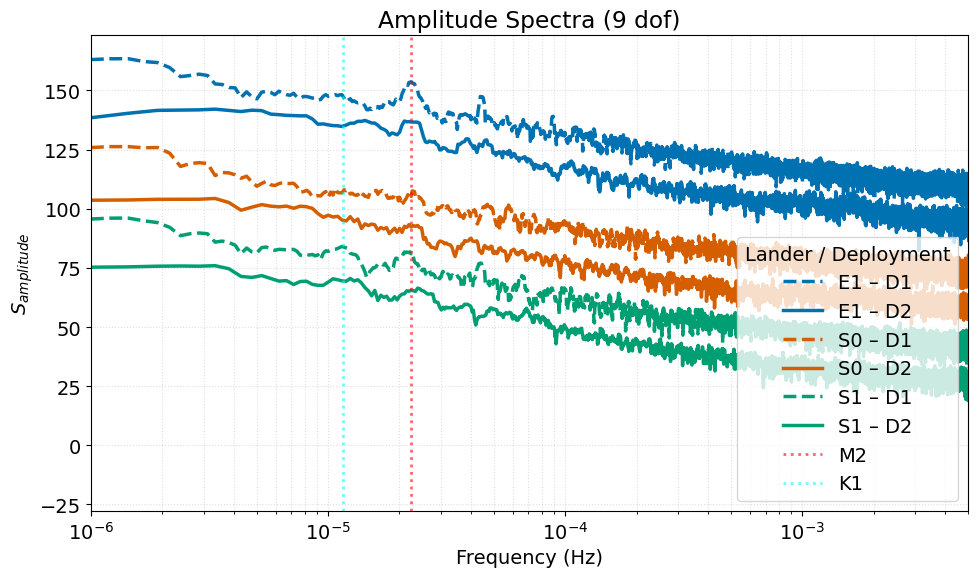

In [52]:
plt.figure(figsize=(10, 6))

sensor_id = ["E1_103071", "S0_103080", "S1_101418"]

# --- Colorblind-safe Okabe–Ito palette ---
lander_color = {
    "E1": "#0072B2",  # blue
    "S0": "#D55E00",  # vermillion
    "S1": "#009E73",  # green
}

# --- Line style encodes deployment ---
deployment_style = {
    1: "--",   # Deployment 1
    2: "-",    # Deployment 2
}
offset = 1
for lander in sensor_id:
    lander_short = lander.split("_")[0]

    for j in deployment_num:
        Sediment = globals()[f"Sediment_D{j}_{lander}"]

        # --- Frequency already in Hz ---
        freq_hz = Sediment["Multi_freq"]
        psd_mean = np.mean(Sediment["Multi_psd"], axis=1)

        # Mask invalid values for log scaling
        m = (freq_hz > 0) & (psd_mean > 0)

        plt.semilogx(
            freq_hz[m],
            psd_mean[m] + offset,
            color=lander_color[lander_short],
            linestyle=deployment_style[j],
            linewidth=2.5,
            label=f"{lander_short} – D{j}"
        )
        offset -= 15
    

# ---------- Plot settings ----------
plt.title("Amplitude Spectra (9 dof)")
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$S_{amplitude}$")
plt.xlim(1e-6, 5e-3)   # adjust to your sample rate & window length
# plt.ylim(1e2, 1.5e3)
plt.grid(True, which="both", linestyle=":", alpha=0.4)

# ---------- Tidal frequencies (convert cpd → Hz) ----------
for name, f_cpd in tidal_freqs_cpd.items():
    f_hz = f_cpd / 86400.0
    if f_hz > 0:
        plt.axvline(
            x=f_hz,
            color=colors[name],
            linestyle=":",
            linewidth=2,
            alpha=0.6,
            label = name
        )

plt.legend(
    title="Lander / Deployment",
    loc="lower right",
    frameon=True
)

plt.tight_layout()
plt.show()


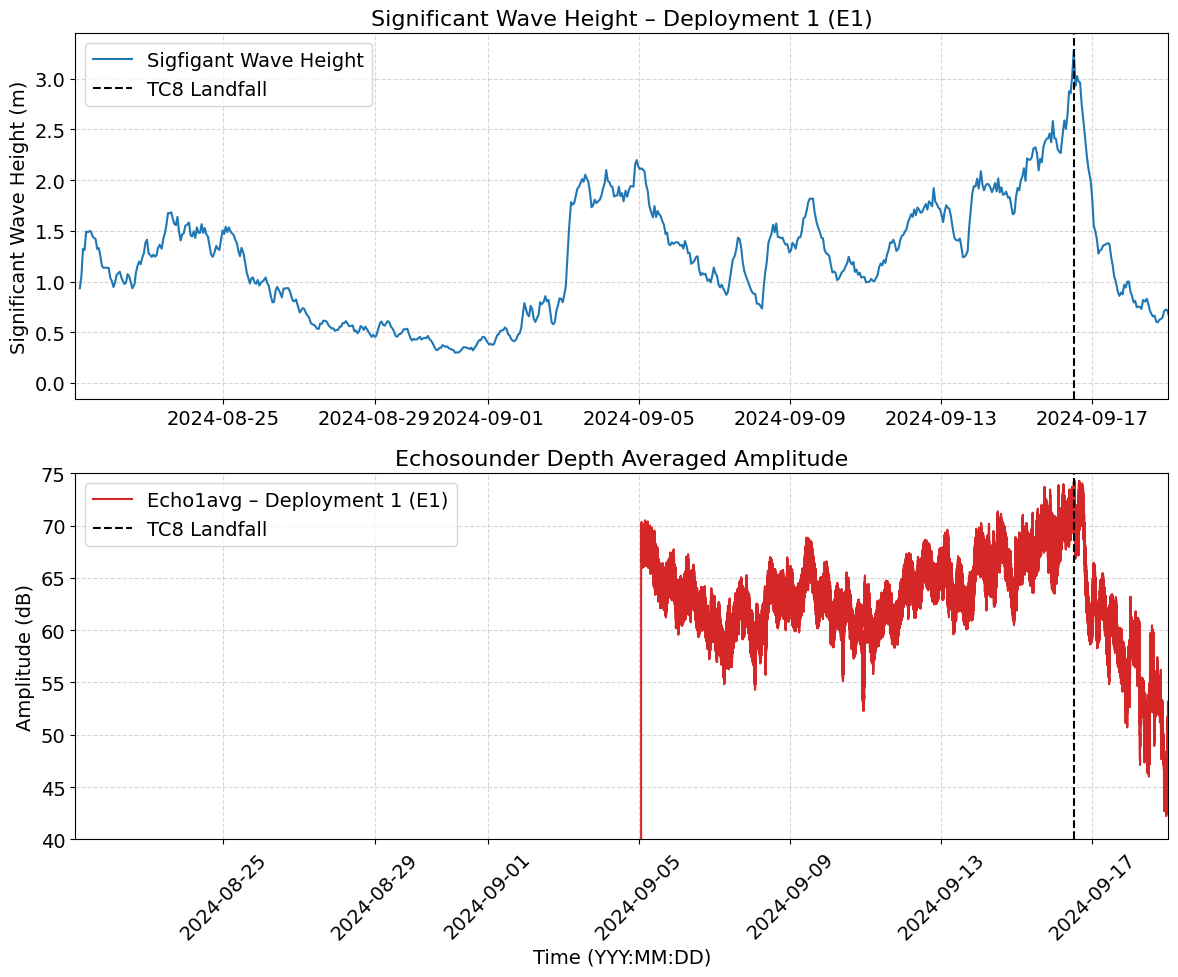

In [36]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# ---------------------------------------------------------
# Plot 1: Significant Wave Height
# ---------------------------------------------------------
ax1.plot(
    waves_D1_E1_103071['Time'],
    waves_D1_E1_103071['SignificantWaveHeight'],
    color='tab:blue',
    label='Sigfigant Wave Height'
)
ax1.set_title('Significant Wave Height – Deployment 1 (E1)', fontsize=16)
ax1.set_ylabel('Significant Wave Height (m)', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)
# ---------------------------------------------------------
# Plot 2: Echo1avg Amplitude
# ---------------------------------------------------------
ax2.plot(
    waves_D1_E1_103071['SedTime'],
    D1E1avg,
    color='tab:red',
    label='Echo1avg – Deployment 1 (E1)'
)
ax2.set_title('Echosounder Depth Averaged Amplitude', fontsize=16)
ax2.set_xlabel('Time (YYY:MM:DD)', fontsize=14)
ax2.set_ylabel('Amplitude (dB)', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)

# Rotate datetime ticks for BOTH plots
for ax in (ax1, ax2):
    ax.set_xlim([datetime.datetime(2024, 8, 21, 2), datetime.datetime(2024, 9, 19)])
    ax.axvline(x=datetime.datetime(2024, 9, 16, 12, 0), color='black', linestyle='--', label='TC8 Landfall')
    ax.legend()
ax2.set_ylim([40,75])
plt.gca().tick_params(axis='x', labelrotation=45)
plt.tight_layout()
plt.show()


In [20]:
#Calculate Correlation coefficient between Sig Wave Height and Echo1avg Amplitude
import scipy.stats as stats
sig_wave_height = waves_D1_E1_103071['SignificantWaveHeight']
echo1avg_amplitude = downsample_antialias(D1E1avg,2,1/3600)[0]
N = len(sig_wave_height)
echo1avg_amplitude = echo1avg_amplitude[:N]  # Ensure same length
correlation_coefficient, p_value = stats.pearsonr(np.ravel(sig_wave_height), echo1avg_amplitude)
print(f"Correlation Coefficient between Significant Wave Height and Echo1avg Amplitude: {correlation_coefficient}")

Correlation Coefficient between Significant Wave Height and Echo1avg Amplitude: 0.4498866834902616
